# Notebook to demo point near point analysis using join QR.

In [1]:
import geofunctions as S
import geopandas as gp
import pyspark.sql.functions as F
from pyspark.sql import Window

### Create LHS points.

In [2]:
lhs = spark.range(20).select(
    F.col("id").alias("lid"),
    S.st_point(F.rand() * 100, F.rand() * 100),
)

### Create RHS points.

In [3]:
rhs = spark.range(30).select(
    F.col("id").alias("rid"),
    S.st_point(F.rand() * 100, F.rand() * 100),
)

### Define search distance and QR cell size.

In [4]:
dist = 10.0
cell = dist * 4.0

### Define window to find nearest row.

In [5]:
over = Window.partitionBy("lid").orderBy("dist")

### Perform spatial join.

In [9]:
res = (
    lhs
    # Here we pass both cell and dist as we are joining point to point.
    .join_qr(rhs, cell, dist)
    .cache()
    .withColumn("dist", S.st_distance())
    .filter(F.col("dist") < dist)
    .withColumn("rn", F.row_number().over(over))
    .filter("rn==1")
    .drop("rn")
    .select(
        "lid",
        "rid",
        S.st_polyline("lgeom", "rgeom").alias("line"),
        "dist",
    )
)

### Let's plot the results.

What is the nearest green point (rhs) to a red point (lhs) within search distance (yellow) ?

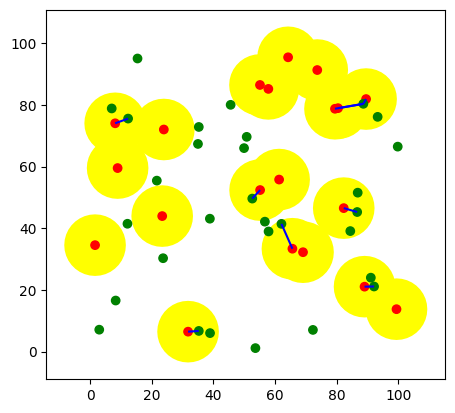

In [10]:
df1 = lhs.select(
    F.col("geom").alias("geometry"),
    F.lit("red").alias("color"),
)
df2 = rhs.select(
    F.col("geom").alias("geometry"),
    F.lit("green").alias("color"),
)
df3 = res.select(
    F.col("line").alias("geometry"),
    F.lit("blue").alias("color"),
)
df4 = lhs.select(
    S.st_buffer("geom", dist).alias("geometry"),
    F.lit("yellow").alias("color"),
)

pdf = df1.unionAll(df2).unionAll(df3).unionAll(df4).toPandas()
pdf.geometry = gp.GeoSeries.from_wkb(pdf.geometry)
gdf = gp.GeoDataFrame(pdf)
_ = gdf.plot(color=pdf.color)